# EXP_10: Passage-Level LIME Explainability

Identifies which retrieved evidence passages most influenced each generated medical answer
using **Local Interpretable Model-agnostic Explanations (LIME)**.

**Method:** Each retrieved passage is treated as a binary interpretable feature (present / absent).
For every question, we create perturbations by masking individual passages, regenerate the answer
via Groq LLaMA 3.3 70B, and measure how answer quality changes. A local linear surrogate model
then ranks passages by their influence on answer quality.

**Target architectures:**
- Evidence-Graded RAG (5 graded passages per question — the top-5 actually fed to the generator, not the wider k=8 candidate pool)
- Query Decomposition RAG (5 passages per question)

**Important:** For Evidence-Graded RAG, we use `graded_contexts` (the 5 passages the generator
actually saw), not `retrieved_contexts` (the 8-passage candidate pool). Attributing influence
to passages the LLM never received would be methodologically invalid.

In [5]:
import sys
sys.path.append("..")

import os
import time
import json
import numpy as np
import pandas as pd
from ast import literal_eval
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from rouge_score import rouge_scorer
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

import config

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", font_scale=1.1)

RESULTS_DIR = config.RESULTS_EVALSETS_DIR
DEEPEVAL_DIR = config.RESULTS_DEEPEVAL_DIR
FIGURES_DIR = config.RESULTS_FIGURES_DIR

## Configuration

In [6]:
ARCHITECTURES = {
    "Evidence-Graded RAG": {
        "eval_file": "evidence_graded_rag_minilm_chroma_20260516_164252.csv",
        "faithfulness_file": "evidence_graded_rag_minilm_faithfulness_20260516_164252.csv",
        "correctness_file": "evidence_graded_rag_minilm_answer_correctness_20260516_164252.csv",
    },
    "Query Decomposition RAG": {
        "eval_file": "decomposition_rag_minilm_k_5_20260518_181816.csv",
        "faithfulness_file": "decomposition_rag_minilm_faithfulness_20260518_181816.csv",
        "correctness_file": "decomposition_rag_minilm_answer_correctness_20260518_181816.csv",
    },
}

SEVERITY_FILE = "golden_dataset_with_severity.csv"

# LIME parameters
NUM_PERTURBATIONS = 32       # exact exhaustive coverage: 2^5 = 32 unique subsets for 5 passages
RIDGE_ALPHA = 1.0            # regularisation for surrogate model
# XAI workloads send ~968 tokens per call (weighted avg across coalition sizes).
# At 4s delay that's ~14,520 TPM per key, exceeding Groq's 12K TPM limit.
# 10s delay → ~5,808 avg TPM, ~8,880 peak TPM — safely under 12K.
XAI_GROQ_DELAY = 10
ROWS_PER_KEY = config.PARALLEL_BUCKET_SIZE  # questions assigned to each API key

# Stratified sample: 30 questions sampled by medical severity tier
# (10 from each of Low / Medium / High). Severity is a domain-native
# 3-bucket categorisation of clinical importance. It produces balanced
# strata (22 Low / 122 Medium / 56 High in the dataset) and ensures XAI
# analysis covers questions across all clinical importance levels.
# Faithfulness was rejected as a stratification variable because 87–94%
# of questions score exactly 1.0, collapsing tertile/quartile splits
# into a single group.
XAI_SAMPLE_SIZE = 30

# Prompts matching the original experiments
EVIDENCE_GRADED_PROMPT = """You are a biomedical research assistant. Use the following research contexts to answer the question.

Context:
{context}

Question: {question}

Instructions:
- Synthesize an answer from the provided context using evidence-based reasoning.
- Draw logical inferences and conclusions from the evidence when a direct statement is not available.
- Cite specific findings, statistics, or conclusions from the context to support your answer.
- Do NOT refuse to answer or state that the context is insufficient. Use whatever relevant evidence is available.

Answer:"""

DECOMPOSITION_PROMPT = """Use the following research contexts to answer the question.

Context:
{context}

Question: {question}

Answer based only on the provided context. Be precise and evidence-based.

Answer:"""

PROMPTS = {
    "Evidence-Graded RAG": EVIDENCE_GRADED_PROMPT,
    "Query Decomposition RAG": DECOMPOSITION_PROMPT,
}

## Groq Client, Scoring & Parallel Infrastructure

In [23]:
class GroqKeyRotator:
    """Cycles through config.GROQ_API_KEYS, rebuilding the LLM client on each rotation."""

    def __init__(self, model=None):
        if not config.GROQ_API_KEYS:
            raise ValueError("config.GROQ_API_KEYS is empty — set GROQ_API_KEY or GROQ_API_KEYS in .env")
        self.api_keys = config.GROQ_API_KEYS
        self.model = model or config.LLM_MODEL
        self.current_idx = 0
        print(f"Initialized GroqKeyRotator with {len(self.api_keys)} API key(s)")

    def get_llm(self):
        return ChatGroq(
            model=self.model,
            api_key=self.api_keys[self.current_idx],
            temperature=0,
            max_tokens=900,
        )

    def rotate(self):
        self.current_idx = (self.current_idx + 1) % len(self.api_keys)


def is_rate_limit_error(e):
    """Check if an exception is a rate limit error."""
    msg = str(e).lower()
    return any(kw in msg for kw in [
        "rate_limit", "rate limit", "429", "too many requests",
        "tokens per", "token limit", "exceeded",
    ])


scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)


def score_answer(generated: str, golden: str) -> float:
    return scorer.score(golden, generated)["rougeL"].fmeasure


def generate_answer(question: str, passages: list[str], prompt_template: str, api_key: str, model: str) -> str:
    """Call Groq to generate an answer from the given passages using a specific API key."""
    context = "\n\n---\n\n".join(passages) if passages else "No context available."
    prompt = PromptTemplate(
        template=prompt_template, input_variables=["context", "question"]
    )
    llm = ChatGroq(model=model, api_key=api_key, temperature=0, max_tokens=900)
    chain = prompt | llm
    result = chain.invoke({"context": context, "question": question})
    return result.content


key_rotator = GroqKeyRotator()

Initialized GroqKeyRotator with 14 API key(s)


## Load Eval Datasets

In [11]:
severity_df = pd.read_csv(config.DATA_PROCESSED_DIR / SEVERITY_FILE)[["question_idx", "severity_tier"]]

datasets = {}
for arch_name, files in ARCHITECTURES.items():
    df = pd.read_csv(RESULTS_DIR / files["eval_file"])

    # Use graded_contexts (the 5 passages actually fed to the generator) for
    # Evidence-Graded RAG; use retrieved_contexts for architectures without grading.
    if "graded_contexts" in df.columns:
        df["graded_contexts"] = df["graded_contexts"].apply(literal_eval)
        df["passages_for_xai"] = df["graded_contexts"]
    else:
        df["retrieved_contexts"] = df["retrieved_contexts"].apply(literal_eval)
        df["passages_for_xai"] = df["retrieved_contexts"]

    df["num_passages"] = df["passages_for_xai"].apply(len)

    # Load faithfulness scores
    faith_df = pd.read_csv(DEEPEVAL_DIR / files["faithfulness_file"])
    faith_col = [c for c in faith_df.columns if "Faithfulness" in c or "faithfulness" in c.lower()]
    if faith_col:
        if "question_idx" in faith_df.columns:
            df = df.merge(faith_df[["question_idx", faith_col[0]]], on="question_idx", how="left")
        else:
            df["faithfulness"] = faith_df[faith_col[0]].values[:len(df)]

    # Load correctness scores
    corr_df = pd.read_csv(DEEPEVAL_DIR / files["correctness_file"])
    corr_col = [c for c in corr_df.columns if "Correctness" in c or "correctness" in c.lower()]
    if corr_col:
        if "question_idx" in corr_df.columns:
            df = df.merge(corr_df[["question_idx", corr_col[0]]], on="question_idx", how="left", suffixes=("", "_corr"))
        else:
            df["answer_correctness"] = corr_df[corr_col[0]].values[:len(df)]

    # Join severity tiers
    df = df.merge(severity_df, on="question_idx", how="left")

    # Stratified sample: 10 questions from each severity tier (Low / Medium / High)
    if XAI_SAMPLE_SIZE < len(df) and "severity_tier" in df.columns:
        per_tier = XAI_SAMPLE_SIZE // 3
        sampled = df.groupby("severity_tier", group_keys=False).apply(
            lambda g: g.sample(n=min(len(g), per_tier), random_state=42)
        ).head(XAI_SAMPLE_SIZE)
        df = sampled.reset_index(drop=True)
        print(f"  Stratified sample by severity: {len(df)} questions")
        print(f"    {df['severity_tier'].value_counts().to_dict()}")
    elif XAI_SAMPLE_SIZE < len(df):
        df = df.sample(n=XAI_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
        print(f"  Random sample: {len(df)} questions")

    datasets[arch_name] = df
    ctx_source = "graded_contexts" if "graded_contexts" in df.columns else "retrieved_contexts"
    print(f"{arch_name}: {len(df)} questions, {df['num_passages'].iloc[0]} passages each (from {ctx_source})")
    print(f"  Columns: {list(df.columns)}")
    print()

  Stratified sample by severity: 30 questions
    {'High': 10, 'Low': 10, 'Medium': 10}
Evidence-Graded RAG: 30 questions, 5 passages each (from graded_contexts)
  Columns: ['Unnamed: 0', 'question_idx', 'question', 'golden_answer', 'golden_contexts', 'query_type', 'pubids_needed', 'route_type', 'route_strategy', 'retrieved_contexts', 'graded_contexts', 'generated_answer', 'hallucination_detected', 'unsupported_claims', 'total_time', 'prompt_tokens', 'completion_tokens', 'total_tokens', 'passages_for_xai', 'num_passages', 'Faithfulness', 'AnswerCorrectness [GEval]', 'severity_tier']

  Stratified sample by severity: 30 questions
    {'High': 10, 'Low': 10, 'Medium': 10}
Query Decomposition RAG: 30 questions, 5 passages each (from retrieved_contexts)
  Columns: ['Unnamed: 0', 'question_idx', 'question', 'golden_answer', 'golden_contexts', 'query_type', 'pubids_needed', 'sub_questions', 'retrieved_contexts', 'generated_answer', 'total_time', 'prompt_tokens', 'completion_tokens', 'total_t

/tmp/ipykernel_4232/2407797552.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df.groupby("severity_tier", group_keys=False).apply(
/tmp/ipykernel_4232/2407797552.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df.groupby("severity_tier", group_keys=False).apply(


In [15]:
for arch, dataset in datasets.items():
    dataset.to_csv(RESULTS_DIR / f"{arch.lower().replace(' ', '_')}_for_xai.csv", index=False)
    print(f"Dataset saved in {str(RESULTS_DIR / f'{arch.lower().replace(' ', '_')}_for_xai.csv')}")
    print(f"  {len(dataset)} questions, {dataset['num_passages'].iloc[0]} passages each")
    print()

Dataset saved in /content/results/eval_datasets/evidence-graded_rag_for_xai.csv
  30 questions, 5 passages each

Dataset saved in /content/results/eval_datasets/query_decomposition_rag_for_xai.csv
  30 questions, 5 passages each



## LIME Perturbation Engine

For each question:
1. **Leave-one-out** perturbations: mask each passage individually (k perturbations)
2. **Random subset** perturbations: randomly include/exclude passages to build a richer local dataset
3. **Full context** baseline: score with all passages present
4. **No context** baseline: score with no passages
5. Fit a Ridge regression on the binary perturbation matrix → scores
6. Passage influence = regression coefficients (higher = more influential)

In [9]:
def generate_perturbation_matrix(n_passages: int, n_random: int = 30, seed: int = 42) -> np.ndarray:
    """Create binary perturbation matrix.

    Rows are perturbations, columns are passages.
    Always includes: all-ones (full context), all-zeros (no context),
    leave-one-out (k rows), and n_random random subsets.
    """
    rng = np.random.RandomState(seed)
    rows = []

    # Full context
    rows.append(np.ones(n_passages, dtype=int))
    # No context
    rows.append(np.zeros(n_passages, dtype=int))
    # Leave-one-out
    for i in range(n_passages):
        row = np.ones(n_passages, dtype=int)
        row[i] = 0
        rows.append(row)
    # Random subsets
    for _ in range(n_random):
        row = rng.randint(0, 2, size=n_passages)
        if row.sum() == 0 or row.sum() == n_passages:
            row[rng.randint(0, n_passages)] ^= 1
        rows.append(row)

    return np.array(rows)


def compute_lime_scores(
    question: str,
    passages: list[str],
    golden_answer: str,
    prompt_template: str,
    api_key: str,
    model: str,
    n_random: int = 30,
    seed: int = 42,
) -> dict:
    """Run LIME for a single question using a dedicated API key."""
    n_passages = len(passages)
    perturbation_matrix = generate_perturbation_matrix(n_passages, n_random, seed)

    scores = []
    for i, mask in enumerate(perturbation_matrix):
        active_passages = [p for p, m in zip(passages, mask) if m == 1]
        answer = generate_answer(question, active_passages, prompt_template, api_key, model)
        s = score_answer(answer, golden_answer)
        scores.append(s)
        time.sleep(XAI_GROQ_DELAY)

    scores = np.array(scores)

    # Fit local surrogate with kernel weighting
    full_context = perturbation_matrix[0]
    distances = np.sqrt(((perturbation_matrix - full_context) ** 2).sum(axis=1))
    kernel_width = np.sqrt(n_passages) * 0.75
    weights = np.exp(-(distances ** 2) / (kernel_width ** 2))

    model_ridge = Ridge(alpha=RIDGE_ALPHA)
    model_ridge.fit(perturbation_matrix, scores, sample_weight=weights)

    return {
        "influence_scores": model_ridge.coef_.tolist(),
        "intercept": float(model_ridge.intercept_),
        "full_context_score": float(scores[0]),
        "no_context_score": float(scores[1]),
        "r_squared": float(model_ridge.score(perturbation_matrix, scores, sample_weight=weights)),
        "n_perturbations": len(scores),
    }

## Parallel LIME Execution Engine

Each API key processes a contiguous slice of questions in its own thread.
Within each thread, questions are processed sequentially with rate-limit delays.

The `resume_lime_from_csv` function identifies questions that failed (rate limits,
transient errors) and reruns only those, merging results back into the existing CSV.

In [11]:
def _run_lime_slice(slice_df, api_key, model, prompt_template, delay, key_idx, done_indices):
    """Process a contiguous slice of questions using LIME with a dedicated API key."""
    results = []
    for row_idx, (_, row) in enumerate(slice_df.iterrows()):
        q_idx = row["question_idx"]
        if q_idx in done_indices:
            continue

        question = row["question"]
        passages = row["passages_for_xai"]
        golden_answer = row["golden_answer"]

        print(f"  [Key {key_idx}] Q{q_idx}: {question[:70]}...")
        try:
            lime_result = compute_lime_scores(
                question, passages, golden_answer, prompt_template,
                api_key, model,
                n_random=NUM_PERTURBATIONS - len(passages) - 2,
            )

            record = {
                "question_idx": q_idx,
                "question": question,
                "num_passages": len(passages),
                "full_context_score": lime_result["full_context_score"],
                "no_context_score": lime_result["no_context_score"],
                "r_squared": lime_result["r_squared"],
                "intercept": lime_result["intercept"],
                "n_perturbations": lime_result["n_perturbations"],
            }
            for p_idx, score in enumerate(lime_result["influence_scores"]):
                record[f"passage_{p_idx}_influence"] = score

            ranking = np.argsort(lime_result["influence_scores"])[::-1]
            record["passage_ranking"] = json.dumps(ranking.tolist())
            record["top1_passage_idx"] = int(ranking[0])
            record["top3_passage_indices"] = json.dumps(ranking[:3].tolist())

            results.append(record)

        except Exception as e:
            print(f"  [Key {key_idx}] ERROR on Q{q_idx}: {e}")
            if is_rate_limit_error(e):
                time.sleep(delay * 3)
            continue

    completed = len(results)
    print(f"[Key {key_idx}] Done — {completed}/{len(slice_df)} questions processed")
    return results


def run_lime_parallel(df, key_rotator, prompt_template, output_file,
                      rows_per_key=None, delay=None):
    """Run LIME across all questions using parallel API keys.

    Distributes questions across available API keys via ThreadPoolExecutor.
    Automatically resumes from checkpoint if output_file already exists.
    """
    rows_per_key = rows_per_key or ROWS_PER_KEY
    delay = delay or XAI_GROQ_DELAY
    api_keys = key_rotator.api_keys

    # Resume from checkpoint if exists
    if output_file.exists():
        existing = pd.read_csv(output_file)
        done_indices = set(existing["question_idx"].values)
        print(f"Resuming from checkpoint: {len(done_indices)} questions already done")
    else:
        existing = pd.DataFrame()
        done_indices = set()

    # Filter to only unfinished questions
    remaining_df = df[~df["question_idx"].isin(done_indices)].copy().reset_index(drop=True)
    if remaining_df.empty:
        print("All questions already completed.")
        return existing

    total_capacity = len(api_keys) * rows_per_key
    if len(remaining_df) > total_capacity:
        print(f"Warning: {len(remaining_df)} rows exceed capacity ({total_capacity}). Truncating.")
        remaining_df = remaining_df.iloc[:total_capacity]

    # Create contiguous slices, one per API key
    slices = []
    for i, key in enumerate(api_keys):
        start = i * rows_per_key
        if start >= len(remaining_df):
            break
        slices.append((key, i, remaining_df.iloc[start: start + rows_per_key]))

    print(f"\n{len(remaining_df)} questions split across {len(slices)} key(s) ({rows_per_key} questions/key max):")
    for key, i, s in slices:
        print(f"  Key {i}: {len(s)} questions")

    ordered_results = [None] * len(slices)
    with ThreadPoolExecutor(max_workers=len(slices)) as executor:
        future_to_idx = {
            executor.submit(
                _run_lime_slice,
                s, key, key_rotator.model, prompt_template, delay, i, done_indices,
            ): idx
            for idx, (key, i, s) in enumerate(slices)
        }
        for future in as_completed(future_to_idx):
            idx = future_to_idx[future]
            try:
                ordered_results[idx] = future.result()
            except Exception as e:
                print(f"[Key {idx}] Thread failed: {e}")
                ordered_results[idx] = []

    # Merge all new results with existing
    all_new_results = []
    for key_results in ordered_results:
        if key_results:
            all_new_results.extend(key_results)

    if all_new_results:
        new_df = pd.DataFrame(all_new_results)
        if not existing.empty:
            final_df = pd.concat([existing, new_df], ignore_index=True)
        else:
            final_df = new_df
    else:
        final_df = existing

    final_df = final_df.sort_values("question_idx").reset_index(drop=True)
    final_df.to_csv(output_file, index=False)
    completed = len(final_df)
    total = len(df)
    print(f"\nCompleted {completed}/{total} questions total")
    print(f"Saved to {output_file}")
    return final_df


def resume_lime_from_csv(df, output_file, key_rotator, prompt_template,
                         rows_per_key=None, delay=None):
    """Resume an interrupted LIME run by reprocessing only missing questions."""
    if not output_file.exists():
        print("No existing results found. Running full LIME computation.")
        return run_lime_parallel(df, key_rotator, prompt_template, output_file,
                                rows_per_key=rows_per_key, delay=delay)

    existing = pd.read_csv(output_file)
    completed_indices = set(existing["question_idx"].values)
    missing_df = df[~df["question_idx"].isin(completed_indices)]

    if missing_df.empty:
        print("All questions already completed.")
        return existing

    print(f"Need to recompute {len(missing_df)} questions.")
    return run_lime_parallel(df, key_rotator, prompt_template, output_file,
                            rows_per_key=rows_per_key, delay=delay)

In [18]:
datasets = {}
for arch_name in ARCHITECTURES:
    df = pd.read_csv(RESULTS_DIR / f"{arch_name.lower().replace(' ', '_')}_for_xai.csv")
    df["passages_for_xai"] = df["passages_for_xai"].apply(literal_eval)
    datasets[arch_name] = df

## Run LIME: Evidence-Graded RAG
Processes a stratified sample of 30 questions for Evidence-Graded RAG. Questions are distributed across
API keys and processed in parallel. Each question requires 32 LLM calls (exact exhaustive perturbations for 5 passages).

Run `resume_lime_from_csv` in the next cell to retry any questions that failed
due to rate limits or transient errors.

In [14]:
arch_name = "Evidence-Graded RAG"
output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"

lime_eg_df = run_lime_parallel(
    datasets[arch_name], key_rotator, PROMPTS[arch_name], output_file, rows_per_key=1
)
print(f"\n{arch_name}: {len(lime_eg_df)} questions completed")


18 questions split across 18 key(s) (1 questions/key max):
  Key 0: 1 questions
  Key 1: 1 questions
  Key 2: 1 questions
  Key 3: 1 questions
  Key 4: 1 questions
  Key 5: 1 questions
  Key 6: 1 questions
  Key 7: 1 questions
  Key 8: 1 questions
  Key 9: 1 questions
  Key 10: 1 questions
  Key 11: 1 questions
  Key 12: 1 questions
  Key 13: 1 questions
  Key 14: 1 questions
  Key 15: 1 questions
  Key 16: 1 questions
  Key 17: 1 questions
  [Key 0] Q9: Pancreas retransplantation:  a second chance for diabetic patients?...
  [Key 1] Q31: Does early migraine treatment shorten time to headache peak and reduce...
  [Key 2] Q141: Does limb-salvage surgery offer patients better quality of life and fu...
  [Key 3] Q58: Metered-dose inhalers. Do health care providers know what to teach?...
  [Key 4] Q74: Does a family meetings intervention prevent depression and anxiety in ...
  [Key 5] Q183: Do preoperative statin therapy and laparoscopic surgery reduce the ris...
  [Key 6] Q149: Combining

In [16]:
# Resume Evidence-Graded RAG — rerun only failed/missing questions
arch_name = "Evidence-Graded RAG"
output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
lime_eg_df = resume_lime_from_csv(
    datasets[arch_name], output_file, key_rotator, PROMPTS[arch_name],
    rows_per_key=1, delay=XAI_GROQ_DELAY)

Need to recompute 12 questions.
Resuming from checkpoint: 18 questions already done

12 questions split across 12 key(s) (1 questions/key max):
  Key 0: 1 questions
  Key 1: 1 questions
  Key 2: 1 questions
  Key 3: 1 questions
  Key 4: 1 questions
  Key 5: 1 questions
  Key 6: 1 questions
  Key 7: 1 questions
  Key 8: 1 questions
  Key 9: 1 questions
  Key 10: 1 questions
  Key 11: 1 questions
  [Key 0] Q19: Is endometrial polyp formation associated with increased expression of...
  [Key 2] Q27: Is robotically assisted laparoscopic radical prostatectomy less invasi...
  [Key 1] Q21: Are performance measurement systems useful?...
  [Key 3] Q80: Does quantitative left ventricular regional wall motion change after f...
  [Key 4] Q82: Does higher body mass index contribute to worse asthma control in an u...
  [Key 5] Q138: Are lifetime prevalence of impetigo, molluscum and herpes infection re...
  [Key 6] Q4: Can elevated troponin I levels predict complicated clinical course and...
  [Key

## Run LIME: Query Decomposition RAG
Processes a stratified sample of 30 questions for Query Decomposition RAG with the same parallel
infrastructure. Run the resume cell below to retry any failed questions.

In [19]:
len(datasets[arch_name]['passages_for_xai'].iloc[0])

5

In [17]:
arch_name = "Query Decomposition RAG"
output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"

lime_qd_df = run_lime_parallel(
    datasets[arch_name], key_rotator, PROMPTS[arch_name], output_file, rows_per_key=1
)
print(f"\n{arch_name}: {len(lime_qd_df)} questions completed")


18 questions split across 18 key(s) (1 questions/key max):
  Key 0: 1 questions
  Key 1: 1 questions
  Key 2: 1 questions
  Key 3: 1 questions
  Key 4: 1 questions
  Key 5: 1 questions
  Key 6: 1 questions
  Key 7: 1 questions
  Key 8: 1 questions
  Key 9: 1 questions
  Key 10: 1 questions
  Key 11: 1 questions
  Key 12: 1 questions
  Key 13: 1 questions
  Key 14: 1 questions
  Key 15: 1 questions
  Key 16: 1 questions
  Key 17: 1 questions
  [Key 0] Q9: Pancreas retransplantation:  a second chance for diabetic patients?...
  [Key 1] Q31: Does early migraine treatment shorten time to headache peak and reduce...
  [Key 2] Q141: Does limb-salvage surgery offer patients better quality of life and fu...
  [Key 3] Q58: Metered-dose inhalers. Do health care providers know what to teach?...
  [Key 5] Q183: Do preoperative statin therapy and laparoscopic surgery reduce the ris...
  [Key 6] Q149: Combining process indicators to evaluate quality of care for surgical ...
  [Key 7] Q120: Treatmen

In [24]:
# Resume Query Decomposition RAG — rerun only failed/missing questions
arch_name = "Query Decomposition RAG"
output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
lime_qd_df = resume_lime_from_csv(
    datasets[arch_name], output_file, key_rotator, PROMPTS[arch_name],
    rows_per_key=1, delay=XAI_GROQ_DELAY)

Need to recompute 16 questions.
Resuming from checkpoint: 14 questions already done

14 questions split across 14 key(s) (1 questions/key max):
  Key 0: 1 questions
  Key 1: 1 questions
  Key 2: 1 questions
  Key 3: 1 questions
  Key 4: 1 questions
  Key 5: 1 questions
  Key 6: 1 questions
  Key 7: 1 questions
  Key 8: 1 questions
  Key 9: 1 questions
  Key 10: 1 questions
  Key 11: 1 questions
  Key 12: 1 questions
  Key 13: 1 questions
  [Key 0] Q183: Do preoperative statin therapy and laparoscopic surgery reduce the ris...
  [Key 1] Q168: How do molecular genotype markers and inflammatory biomarkers differ i...
  [Key 2] Q10: Immune suppression by lysosomotropic amines and cyclosporine on T-cell...
  [Key 3] Q118: Health care for immigrants in Europe: is there still consensus among c...
  [Key 4] Q19: Is endometrial polyp formation associated with increased expression of...
  [Key 5] Q21: Are performance measurement systems useful?...
  [Key 6] Q27: Is robotically assisted laparosco

In [27]:
# Resume Query Decomposition RAG — rerun only failed/missing questions
arch_name = "Query Decomposition RAG"
output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
lime_qd_df = resume_lime_from_csv(
    datasets[arch_name], output_file, key_rotator, PROMPTS[arch_name],
    rows_per_key=1, delay=XAI_GROQ_DELAY)

Need to recompute 2 questions.
Resuming from checkpoint: 28 questions already done

2 questions split across 2 key(s) (1 questions/key max):
  Key 0: 1 questions
  Key 1: 1 questions
  [Key 0] Q52: Does context matter for the relationship between deprivation and all-c...
  [Key 1] Q90: Does Viral Co-Infection Influence the Severity of Acute Respiratory In...
[Key 1] Done — 1/1 questions processed
[Key 0] Done — 1/1 questions processed

Completed 30/30 questions total
Saved to /content/results/eval_datasets/lime_passage_scores_query_decomposition_rag.csv


## Analysis: Passage Influence Distribution

In [28]:
for arch_name in ARCHITECTURES:
    output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        print(f"Skipping {arch_name}: no results yet")
        continue

    lime_df = pd.read_csv(output_file)
    influence_cols = [c for c in lime_df.columns if c.startswith("passage_") and c.endswith("_influence")]
    n_passages = len(influence_cols)

    print(f"\n{'='*50}")
    print(f"{arch_name} — {len(lime_df)} questions, {n_passages} passages")
    print(f"{'='*50}")

    # Summary statistics
    influence_matrix = lime_df[influence_cols].values
    mean_influence = influence_matrix.mean(axis=0)
    print(f"\nMean influence per passage position:")
    for i, m in enumerate(mean_influence):
        bar = "█" * int(abs(m) * 50)
        sign = "+" if m >= 0 else "-"
        print(f"  Passage {i}: {sign}{abs(m):.4f} {bar}")

    print(f"\nSurrogate model R²: {lime_df['r_squared'].mean():.3f} (mean), {lime_df['r_squared'].median():.3f} (median)")
    print(f"Full-context ROUGE-L: {lime_df['full_context_score'].mean():.3f}")
    print(f"No-context ROUGE-L: {lime_df['no_context_score'].mean():.3f}")


Evidence-Graded RAG — 30 questions, 5 passages

Mean influence per passage position:
  Passage 0: +0.0201 █
  Passage 1: +0.0179 
  Passage 2: +0.0021 
  Passage 3: +0.0018 
  Passage 4: -0.0043 

Surrogate model R²: 0.573 (mean), 0.577 (median)
Full-context ROUGE-L: 0.182
No-context ROUGE-L: 0.112

Query Decomposition RAG — 30 questions, 5 passages

Mean influence per passage position:
  Passage 0: +0.0127 
  Passage 1: +0.0407 ██
  Passage 2: +0.0112 
  Passage 3: +0.0107 
  Passage 4: +0.0073 

Surrogate model R²: 0.582 (mean), 0.637 (median)
Full-context ROUGE-L: 0.291
No-context ROUGE-L: 0.077


## Visualisation: LIME Influence Heatmap

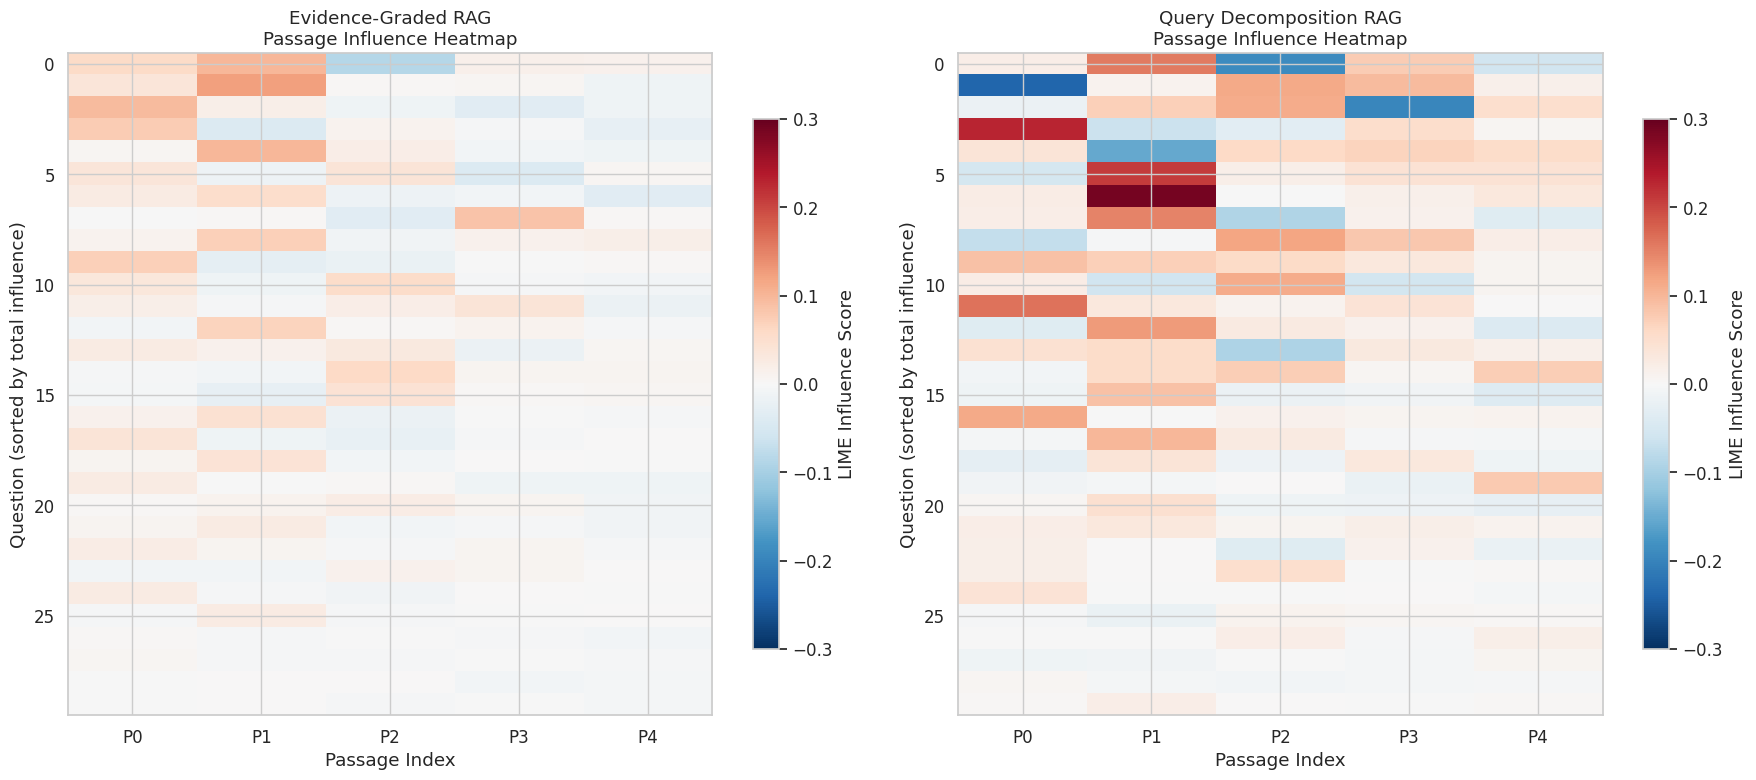

Saved: lime_influence_heatmap.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax_idx, arch_name in enumerate(ARCHITECTURES):
    output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue

    lime_df = pd.read_csv(output_file)
    influence_cols = [c for c in lime_df.columns if c.startswith("passage_") and c.endswith("_influence")]
    influence_matrix = lime_df[influence_cols].values

    # Sort questions by total absolute influence for visual clarity
    sort_idx = np.argsort(np.abs(influence_matrix).sum(axis=1))[::-1]
    display_matrix = influence_matrix[sort_idx[:30]]  # all sampled questions

    ax = axes[ax_idx]
    im = ax.imshow(display_matrix, aspect="auto", cmap="RdBu_r", vmin=-0.3, vmax=0.3)
    ax.set_xlabel("Passage Index")
    ax.set_ylabel("Question (sorted by total influence)")
    ax.set_title(f"{arch_name}\nPassage Influence Heatmap")
    ax.set_xticks(range(len(influence_cols)))
    ax.set_xticklabels([f"P{i}" for i in range(len(influence_cols))])
    plt.colorbar(im, ax=ax, label="LIME Influence Score", shrink=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lime_influence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lime_influence_heatmap.png")

## Visualisation: Mean Influence by Passage Position

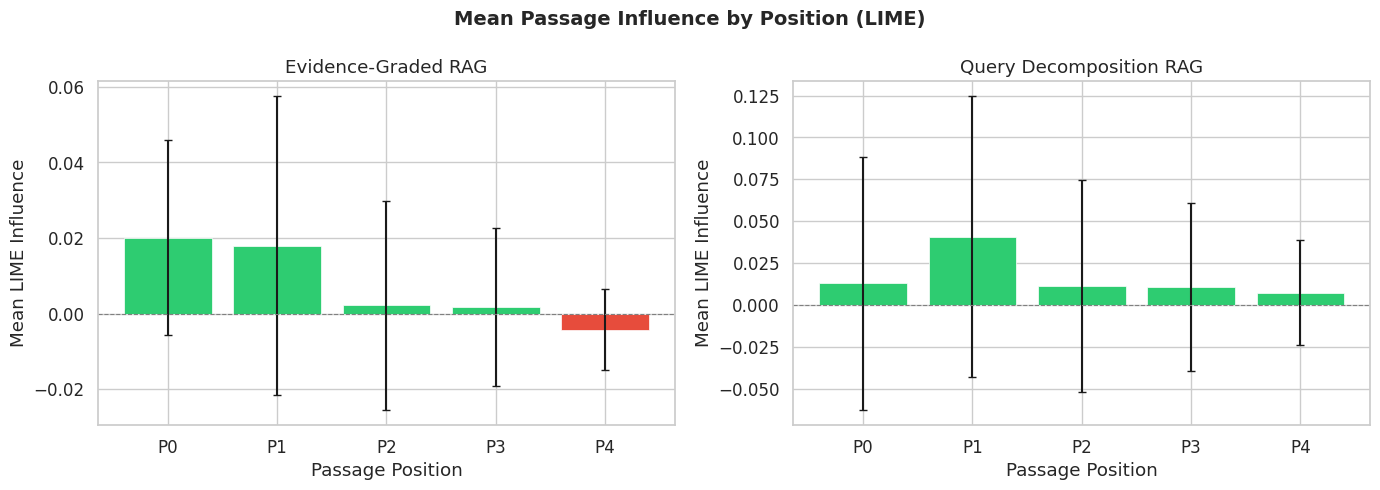

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, arch_name in enumerate(ARCHITECTURES):
    output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue

    lime_df = pd.read_csv(output_file)
    influence_cols = [c for c in lime_df.columns if c.startswith("passage_") and c.endswith("_influence")]
    influence_matrix = lime_df[influence_cols].values

    mean_influence = influence_matrix.mean(axis=0)
    std_influence = influence_matrix.std(axis=0)

    ax = axes[ax_idx]
    colours = ["#2ecc71" if v >= 0 else "#e74c3c" for v in mean_influence]
    bars = ax.bar(range(len(mean_influence)), mean_influence, yerr=std_influence,
                  color=colours, capsize=3, edgecolor="white", linewidth=0.5)
    ax.axhline(y=0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Passage Position")
    ax.set_ylabel("Mean LIME Influence")
    ax.set_title(f"{arch_name}")
    ax.set_xticks(range(len(mean_influence)))
    ax.set_xticklabels([f"P{i}" for i in range(len(mean_influence))])

plt.suptitle("Mean Passage Influence by Position (LIME)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lime_mean_influence_by_position.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisation: Top-1 Passage Distribution

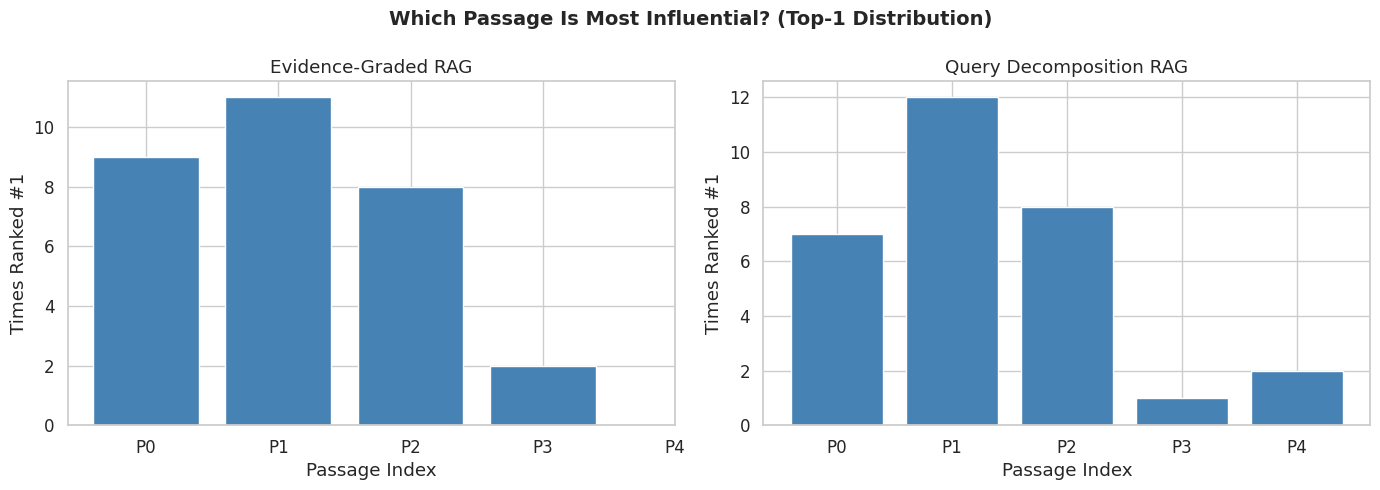

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, arch_name in enumerate(ARCHITECTURES):
    output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue

    lime_df = pd.read_csv(output_file)
    n_passages = len([c for c in lime_df.columns if c.startswith("passage_") and c.endswith("_influence")])

    ax = axes[ax_idx]
    top1_counts = lime_df["top1_passage_idx"].value_counts().sort_index()
    ax.bar(top1_counts.index, top1_counts.values, color="steelblue", edgecolor="white")
    ax.set_xlabel("Passage Index")
    ax.set_ylabel("Times Ranked #1")
    ax.set_title(f"{arch_name}")
    ax.set_xticks(range(n_passages))
    ax.set_xticklabels([f"P{i}" for i in range(n_passages)])

plt.suptitle("Which Passage Is Most Influential? (Top-1 Distribution)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lime_top1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlation: LIME Influence vs Faithfulness

In [32]:
for arch_name, df in datasets.items():
    output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue

    lime_df = pd.read_csv(output_file)
    influence_cols = [c for c in lime_df.columns if c.startswith("passage_") and c.endswith("_influence")]

    # Max influence per question = how much the best passage contributes
    lime_df["max_influence"] = lime_df[influence_cols].max(axis=1)
    lime_df["influence_spread"] = lime_df[influence_cols].max(axis=1) - lime_df[influence_cols].min(axis=1)

    # Merge with faithfulness
    faith_cols = [c for c in df.columns if "faithfulness" in c.lower() or "Faithfulness" in c]
    if faith_cols:
        merged = lime_df.merge(
            df[["question_idx"] + faith_cols],
            on="question_idx", how="inner"
        )
        faith_col = faith_cols[0]

        print(f"\n{arch_name}:")
        corr_max = merged["max_influence"].corr(merged[faith_col])
        corr_spread = merged["influence_spread"].corr(merged[faith_col])
        print(f"  Pearson(max_influence, faithfulness) = {corr_max:.3f}")
        print(f"  Pearson(influence_spread, faithfulness) = {corr_spread:.3f}")


Evidence-Graded RAG:
  Pearson(max_influence, faithfulness) = 0.111
  Pearson(influence_spread, faithfulness) = 0.098

Query Decomposition RAG:
  Pearson(max_influence, faithfulness) = nan
  Pearson(influence_spread, faithfulness) = nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Summary Table

In [33]:
summary_rows = []
for arch_name in ARCHITECTURES:
    output_file = RESULTS_DIR / f"lime_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue
    lime_df = pd.read_csv(output_file)
    influence_cols = [c for c in lime_df.columns if c.startswith("passage_") and c.endswith("_influence")]
    influence_matrix = lime_df[influence_cols].values

    summary_rows.append({
        "Architecture": arch_name,
        "N Questions": len(lime_df),
        "N Passages": len(influence_cols),
        "Mean R²": f"{lime_df['r_squared'].mean():.3f}",
        "Full-Ctx ROUGE-L": f"{lime_df['full_context_score'].mean():.3f}",
        "No-Ctx ROUGE-L": f"{lime_df['no_context_score'].mean():.3f}",
        "Mean Max Influence": f"{influence_matrix.max(axis=1).mean():.4f}",
        "Mean Influence Spread": f"{(influence_matrix.max(axis=1) - influence_matrix.min(axis=1)).mean():.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Architecture,N Questions,N Passages,Mean R²,Full-Ctx ROUGE-L,No-Ctx ROUGE-L,Mean Max Influence,Mean Influence Spread
0,Evidence-Graded RAG,30,5,0.573,0.182,0.112,0.0465,0.0652
1,Query Decomposition RAG,30,5,0.582,0.291,0.077,0.0909,0.1391
